<div style="text-align: center; font-size: 32px;">
<b>PREDIKSI KEBANGKRUTAN PERUSAHAAN ASURANSI DI INDONESIA MENGGUNAKAN ARTIFICIAL NEURAL NETWORKS
</b>
</div>

**Importing Library**

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 9.2 MB/s eta 0:00:00


In [2]:

# data manipulation tools
import pandas as pd
import numpy as np
import re

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection tools
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


# ignore warnings
import warnings
warnings.filterwarnings('ignore')\

# time module
import time
import itertools

# data preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

# handing imbalanced datasets
from imblearn.over_sampling import SMOTE

# tools for create ANN arcitecture
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization,LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.utils import to_categorical

# model evaluation tools
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

# hyperparameter tuning tools
import optuna
from optuna.samplers import TPESampler

# Ranodm State
RANDOM_STATE=42

# ignore warnings
import warnings
warnings.filterwarnings('ignore')



**Importing Dataset**

In [94]:
data = pd.read_csv('/content/Data Bersih.csv')
data

,Sub_Sektor,No,Nama_Perusahaan,Tahun,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,...,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Label
0,Asuransi Jiwa,2,PT AIA Financial,2015,0.52,0.18,0.79,3.85,0.09,0.03,...,0,0,31860954000000,-0.2480,-0.1817,0.5921,0.3478,0.2727,1.0310,Potensi Bangkrut
1,Asuransi Jiwa,2,PT AIA Financial,2016,0.53,0.18,0.78,3.61,0.09,0.03,...,0,0,35767906000000,0.4761,-0.1806,0.6244,0.1943,0.2912,0.9293,Potensi Bangkrut
2,Asuransi Jiwa,2,PT AIA Financial,2017,0.41,0.15,0.76,3.25,0.10,0.03,...,0,0,44937292000000,0.1703,-0.2670,0.5252,0.0811,0.3226,0.6619,Potensi Bangkrut
3,Asuransi Jiwa,2,PT AIA Financial,2018,0.45,0.22,0.76,3.22,0.08,0.02,...,0,0,46562563000000,-0.1763,-0.2564,0.5998,0.3103,0.3258,0.9795,Potensi Bangkrut
4,Asuransi Jiwa,2,PT AIA Financial,2019,0.59,0.30,0.76,3.22,0.14,0.04,...,0,0,50043024000000,0.2158,-0.1808,0.5149,0.0604,0.3265,0.7210,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,Asuransi Sosial,148,BPJS Ketenagakerjaan,2020,5.37,0.89,0.23,0.30,0.02,0.00,...,0,0,15801971000000,-0.1372,2.5175,0.4250,0.1898,3.5440,6.6763,Perusahaan Sehat
1167,Asuransi Sosial,148,BPJS Ketenagakerjaan,2021,5.29,1.05,0.25,0.33,0.01,0.00,...,0,0,16149482000000,0.1508,2.8335,0.4275,0.0796,3.2158,6.5564,Perusahaan Sehat
1168,Asuransi Sosial,148,BPJS Ketenagakerjaan,2022,4.86,0.99,0.22,0.28,0.01,0.00,...,0,0,16468014000000,-0.0317,2.3790,0.4487,0.0714,3.6915,6.5906,Perusahaan Sehat
1169,Asuransi Sosial,148,BPJS Ketenagakerjaan,2023,5.77,0.07,0.26,0.35,0.10,0.03,...,0,0,16787071000000,0.0580,2.4883,0.5276,0.2387,3.0053,6.2599,Perusahaan Sehat


**Feature Selection: menghapus bebebrapa fitur yang kurang relevan dengan pemodelan yang akan dilakukan**

In [95]:
data = data.drop(columns=['Sub_Sektor','No','Nama_Perusahaan','Z_Score','Z_Score_X1','Z_Score_X2','Z_Score_X3','Z_Score_X4','Tahun'])
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Label
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.2480,Potensi Bangkrut
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.4761,Potensi Bangkrut
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.1703,Potensi Bangkrut
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.1763,Potensi Bangkrut
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.2158,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.1372,Perusahaan Sehat
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.1508,Perusahaan Sehat
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.0317,Perusahaan Sehat
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.0580,Perusahaan Sehat


In [96]:
print(data[['Total_Asset', 'Pertumbuhan_Revenue', 'Label']])

         Total_Asset  Pertumbuhan_Revenue             Label
0     31860954000000              -0.2480  Potensi Bangkrut
1     35767906000000               0.4761  Potensi Bangkrut
2     44937292000000               0.1703  Potensi Bangkrut
3     46562563000000              -0.1763  Potensi Bangkrut
4     50043024000000               0.2158  Potensi Bangkrut
...              ...                  ...               ...
1166  15801971000000              -0.1372  Perusahaan Sehat
1167  16149482000000               0.1508  Perusahaan Sehat
1168  16468014000000              -0.0317  Perusahaan Sehat
1169  16787071000000               0.0580  Perusahaan Sehat
1170  16807910000000               0.0782  Perusahaan Sehat

[1171 rows x 3 columns]


Ubah label jadi kategori

In [97]:
#Tesss
#Asumsikan kolom target Anda adalah df['STATUS_RISIKO'].

import pandas as pd

# 1. Definisikan kamus pemetaan (mapping dictionary)
RISK_MAPPING = {
    'Potensi Bangkrut': 0,
    'Area abu-abu': 1,
    'Perusahaan Sehat': 2
}

# 2. Terapkan pemetaan ke kolom target Anda
# Ganti 'Kolom_Target' dengan nama kolom yang benar di DataFrame Anda.
# Jika nama kolom target Anda adalah 'STATUS_RISIKO', gunakan itu.
data['Label_ENCODED'] = data['Label'].map(RISK_MAPPING)

# 3. Verifikasi hasilnya
print("Distribution of Each Category:")
print(data['Label_ENCODED'].value_counts().sort_index())

Distribution of Each Category:
Label_ENCODED
0    391
1    213
2    567
Name: count, dtype: int64


In [98]:
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Label,Label_ENCODED
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.2480,Potensi Bangkrut,0
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.4761,Potensi Bangkrut,0
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.1703,Potensi Bangkrut,0
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.1763,Potensi Bangkrut,0
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.2158,Potensi Bangkrut,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.1372,Perusahaan Sehat,2
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.1508,Perusahaan Sehat,2
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.0317,Perusahaan Sehat,2
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.0580,Perusahaan Sehat,2


In [100]:
print(data[['Total_Asset', 'Pertumbuhan_Revenue', 'Label','Label_ENCODED']])

         Total_Asset  Pertumbuhan_Revenue             Label  Label_ENCODED
0     31860954000000              -0.2480  Potensi Bangkrut              0
1     35767906000000               0.4761  Potensi Bangkrut              0
2     44937292000000               0.1703  Potensi Bangkrut              0
3     46562563000000              -0.1763  Potensi Bangkrut              0
4     50043024000000               0.2158  Potensi Bangkrut              0
...              ...                  ...               ...            ...
1166  15801971000000              -0.1372  Perusahaan Sehat              2
1167  16149482000000               0.1508  Perusahaan Sehat              2
1168  16468014000000              -0.0317  Perusahaan Sehat              2
1169  16787071000000               0.0580  Perusahaan Sehat              2
1170  16807910000000               0.0782  Perusahaan Sehat              2

[1171 rows x 4 columns]


In [50]:
#TIDAK USAH DIPAKAI
# Encode label
#le = LabelEncoder()
#data["Label"] = le.fit_transform(data["Label"])

**Splitting Dataset**

In [101]:
#hapus kolom encode agar tidak duplikat output
data=data.drop(columns=['Label'])

data = data.rename(columns={'Label_ENCODED': 'Label'})

X = data.drop(columns=['Label'])
y = data['Label']


In [102]:
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Label
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.2480,0
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.4761,0
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.1703,0
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.1763,0
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.2158,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.1372,2
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.1508,2
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.0317,2
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.0580,2


In [ ]:
"""
# Encode label
le = LabelEncoder()
data["Label"] = le.fit_transform(data["Label_ENCODED"])


data["Label"] = le.fit_transform(data["Label_ENCODED"])
"""

In [103]:
data['Label'].value_counts()

,count
Label,
2,567
0,391
1,213


In [ ]:
"""
# Ga usah dipakaiiiiiiiiiiiiiiii
# Fit encoder di y sebelum resample
le = LabelEncoder()
y = le.fit_transform(y)

for i, class_label in enumerate(le.classes_):
    print(f"{class_label} -> {i}")
  """

'\n# Ga usah dipakaiiiiiiiiiiiiiiii\n# Fit encoder di y sebelum resample\nle = LabelEncoder()\ny = le.fit_transform(y)\n\nfor i, class_label in enumerate(le.classes_):\n    print(f"{class_label} -> {i}")\n  '

In [104]:
# Optimal Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= RANDOM_STATE,stratify=y)

In [105]:
# Feature Scaling
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

In [106]:
# Melakukan Scaling pada kolom yang berbeda
# Kolom

cols_robust = ['Current_Ratio', 'Cash_Ratio', 'DER', 'NPM', 'ROA', 'ROE',
               'Kepemilikan_Mayoritas', 'Insider_Ownership', 'BoC_Education',
               'TMT_Education_DD', 'TMT_Education_DK', 'Pertumbuhan_Revenue']

cols_standard = ['DAR', 'Komisaris_Independen', 'BoC_Size', 'TMT_Size_DK',
                 'TMT_Size_DD', 'Total_Asset']

In [107]:
# Fit hanya di training data
from sklearn.preprocessing import RobustScaler

X_train_robust_scaled = pd.DataFrame(
    scaler_robust.fit_transform(X_train[cols_robust]),
    columns=cols_robust,
    index=X_train.index
)



In [108]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
X_train_standard_scaled = pd.DataFrame(
    scaler_standard.fit_transform(X_train[cols_standard]),
    columns=cols_standard,
    index=X_train.index
)

In [109]:

# Untuk test data, langsung transform pakai scaler yang sudah fit di train
X_test_robust_scaled = pd.DataFrame(
    scaler_robust.transform(X_test[cols_robust]),
    columns=cols_robust,
    index=X_test.index
)

X_test_standard_scaled = pd.DataFrame(
    scaler_standard.transform(X_test[cols_standard]),
    columns=cols_standard,
    index=X_test.index
)

# Gabungkan kembali menjadi satu DataFrame
X_train_scaled = pd.concat([X_train_robust_scaled, X_train_standard_scaled], axis=1)
X_test_scaled = pd.concat([X_test_robust_scaled, X_test_standard_scaled], axis=1)
X_train = X_train_scaled
X_test = X_test_scaled

In [110]:
# split X_test and y_test into X_test, X_val, y_test, y_val with test_size=0.5
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state= RANDOM_STATE,stratify=y_test)
X_test.shape, X_val.shape, y_test.shape, y_val.shape

((117, 18), (118, 18), (117,), (118,))

**Handling Imbalance Dataset**

In [111]:
# Handle Imbalanced Data with SMOTE
smote = SMOTE(random_state= RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [112]:
# Create DataFrame for train, test, and validation sets
Data_train = pd.DataFrame(X_train_res, columns=X.columns)
Data_train['Label'] = y_train_res

Data_test = pd.DataFrame(X_test, columns=X.columns)
Data_test['Label'] = y_test

Data_val = pd.DataFrame(X_val, columns=X.columns)
Data_val['Label'] = y_val

In [113]:
# Split X and y for train, test, and validation sets
X_train = Data_train.drop(columns=['Label'])
y_train = Data_train['Label']

X_test = Data_test.drop(columns=['Label'])
y_test = Data_test['Label']

X_val = Data_val.drop(columns=['Label'])
y_val = Data_val['Label']


# **Searching An Architecture Neural Networks**

[I 2025-10-19 03:59:42,971] A new study created in memory with name: no-name-1c10eee2-f1c6-40a8-a6a3-60d491d64ae4
[I 2025-10-19 03:59:48,080] Trial 0 finished with value: 0.8559321761131287 and parameters: {'n_layers': 3, 'units_0': 245, 'activation_0': 'leaky_relu', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 216, 'activation_1': 'softmax', 'use_dropout_1': False, 'use_batchnorm_1': False, 'units_2': 89, 'activation_2': 'tanh', 'use_dropout_2': True, 'dropout_rate_2': 0.12602063719411183, 'use_batchnorm_2': False, 'lr': 0.004138040112561018, 'batch_size': 64}. Best is trial 0 with value: 0.8559321761131287.
[I 2025-10-19 03:59:55,688] Trial 1 finished with value: 0.8220338821411133 and parameters: {'n_layers': 3, 'units_0': 59, 'activation_0': 'selu', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 202, 'activation_1': 'relu', 'use_dropout_1': False, 'use_batchnorm_1': True, 'units_2': 170, 'activation_2': 'softmax', 'use_dropout_2': True, 'dropout_rate_2

Best trial: {'n_layers': 3, 'units_0': 195, 'activation_0': 'leaky_relu', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 100, 'activation_1': 'relu', 'use_dropout_1': True, 'dropout_rate_1': 0.446547478835302, 'use_batchnorm_1': False, 'units_2': 45, 'activation_2': 'tanh', 'use_dropout_2': True, 'dropout_rate_2': 0.12980727234678432, 'use_batchnorm_2': True, 'lr': 0.0017499335685390856, 'batch_size': 64}
Epoch 1/200
15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4829 - loss: 1.1624
Epoch 1: val_accuracy improved from -inf to 0.72034, saving model to best_model_final.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5119 - loss: 1.1101 - val_accuracy: 0.7203 - val_loss: 0.7321 - learning_rate: 0.0017
Epoch 2/200
16/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6897 - loss: 0.7932 
Epoch 2: val_accuracy improved from 0.72034 to 0.76271, saving model to best_model_final.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6858 - loss: 0.7932 - val

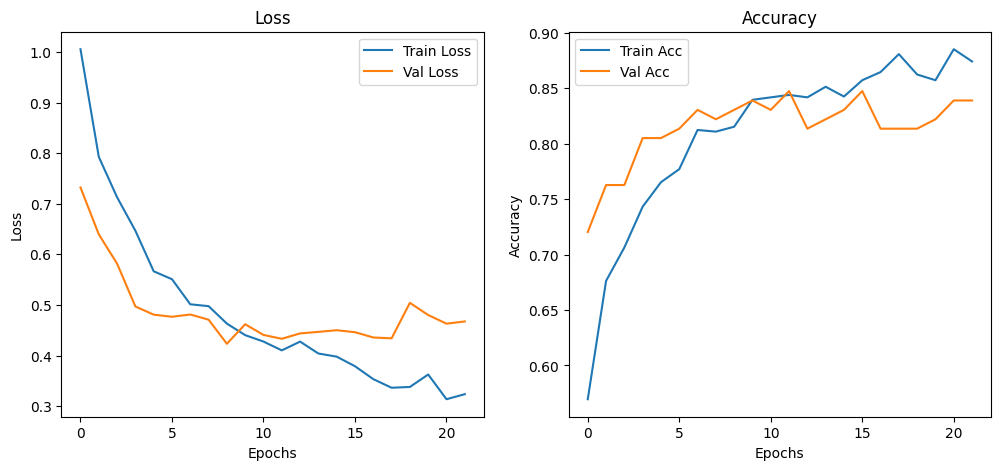

In [117]:
import optuna
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ===============================
# 🔒 Seed untuk reproducibility
# ===============================
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ===============================
# 🔑 One-hot encoding label
# ===============================
num_classes = len(set(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

# ===============================
# 🎯 Objective function Optuna
# ===============================
def objective(trial):
    model = Sequential()

    # Jumlah hidden layer (2–5)
    n_layers = trial.suggest_int("n_layers", 2, 5)

    # Hidden layer pertama
    prev_units = trial.suggest_int("units_0", 32, 256)
    activation = trial.suggest_categorical("activation_0", ["relu", "tanh", "selu",'sigmoid','softmax','leaky_relu'])
    model.add(Dense(prev_units, activation=activation, input_dim=X_train.shape[1]))

    # Opsi Dropout & BatchNorm di layer pertama
    if trial.suggest_categorical("use_dropout_0", [True, False]):
        rate = trial.suggest_float("dropout_rate_0", 0.1, 0.5)
        model.add(Dropout(rate))
    if trial.suggest_categorical("use_batchnorm_0", [True, False]):
        model.add(BatchNormalization())

    # Hidden layer berikutnya
    for i in range(1, n_layers):
        min_units, max_units = 16, 256
        if i == n_layers - 1:
            max_units = prev_units  # constraint: tidak lebih besar dari layer sebelumnya
        units = trial.suggest_int(f"units_{i}", min_units, max_units)
        activation = trial.suggest_categorical(f"activation_{i}", ["relu", "tanh", "selu",'sigmoid','softmax','leaky_relu'])
        model.add(Dense(units, activation=activation))
        prev_units = units

        # Opsi Dropout & BatchNorm
        if trial.suggest_categorical(f"use_dropout_{i}", [True, False]):
            rate = trial.suggest_float(f"dropout_rate_{i}", 0.1, 0.5)
            model.add(Dropout(rate))
        if trial.suggest_categorical(f"use_batchnorm_{i}", [True, False]):
            model.add(BatchNormalization())

    # Output layer
    model.add(Dense(num_classes, activation="softmax"))

    # Optimizer
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint("best_model_optuna.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=0)
    ]

    # Training
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=100,  # cukup 100 karena ada early stopping
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
        callbacks=callbacks,
        verbose=0
    )

    return max(history.history["val_accuracy"])


# ===============================
# 🚀 Jalankan Optuna
# ===============================
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=150)  # bisa ditingkatkan sesuai kebutuhan

print("Best trial:", study.best_trial.params)


# ===============================
# 🔁 Retrain model dengan best params
# ===============================
best_params = study.best_trial.params
model = Sequential()

# Hidden layer pertama
prev_units = best_params["units_0"]
activation = best_params["activation_0"]
model.add(Dense(prev_units, activation=activation, input_dim=X_train.shape[1]))

if best_params.get("use_dropout_0", False):
    model.add(Dropout(best_params["dropout_rate_0"]))
if best_params.get("use_batchnorm_0", False):
    model.add(BatchNormalization())

# Hidden layer berikutnya
for i in range(1, best_params["n_layers"]):
    max_units = prev_units if i == best_params["n_layers"] - 1 else 256
    units = best_params[f"units_{i}"]
    activation = best_params[f"activation_{i}"]
    model.add(Dense(units, activation=activation))
    prev_units = units

    if best_params.get(f"use_dropout_{i}", False):
        model.add(Dropout(best_params[f"dropout_rate_{i}"]))
    if best_params.get(f"use_batchnorm_{i}", False):
        model.add(BatchNormalization())

# Output layer
model.add(Dense(num_classes, activation="softmax"))

optimizer = Adam(learning_rate=best_params["lr"])
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_final.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=200,
    batch_size=best_params["batch_size"],
    callbacks=callbacks,
    verbose=1
)

# ===============================
# 📊 Plot Loss & Accuracy
# ===============================
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [118]:
model.summary()

Model: "sequential_471"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1923 (Dense)              │ (None, 195)            │         3,705 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1924 (Dense)              │ (None, 100)            │        19,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_655 (Dropout)           │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1925 (Dense)              │ (None, 45)             │         4,545 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_656 (Dropout)           │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_452         │ (None, 45)             │           180 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1926 (Dense)              │ (None, 3)              │           138 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,326 (329.40 KB)

 Trainable params: 28,078 (109.68 KB)

 Non-trainable params: 90 (360.00 B)

 Optimizer params: 56,158 (219.37 KB)

{'n_layers': 4, 'units_0': 101, 'activation_0': 'tanh', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 67, 'activation_1': 'selu', 'use_dropout_1': True, 'dropout_rate_1': 0.17155679861891207, 'use_batchnorm_1': True, 'units_2': 146, 'activation_2': 'selu', 'use_dropout_2': False, 'use_batchnorm_2': False, 'units_3': 37, 'activation_3': 'leaky_relu', 'use_dropout_3': False, 'use_batchnorm_3': False, 'lr': 0.0018994610036140445, 'batch_size': 32}
Epoch 1/200

In [119]:
# Arsitektur layer tetap
ARCHITECTURE = [
    {"units": 101, "activation": "tanh"},
    {"units": 67, "activation": "selu"},
    {"units": 146, "activation": "selu"},
    {"units": 37, "activation": "leaky_relu"}
]

def create_model(trial):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))  # sesuaikan input dim

    for i, layer in enumerate(ARCHITECTURE):
        # Regularisasi
        reg_type = trial.suggest_categorical(f"reg_{i}", ["l1", "l2", None])
        reg_strength = trial.suggest_float(f"reg_strength_{i}", 1e-5, 1e-2, log=True)

        if reg_type == "l1":
            kernel_reg = regularizers.l1(reg_strength)
        elif reg_type == "l2":
            kernel_reg = regularizers.l2(reg_strength)
        else:
            kernel_reg = None

        model.add(Dense(layer["units"], activation=layer["activation"], kernel_regularizer=kernel_reg))

        # Dropout
        if trial.suggest_categorical(f"use_dropout_{i}", [True, False]):
            dropout_rate = trial.suggest_float(f"dropout_rate_{i}", 0.1, 0.5)
            model.add(Dropout(dropout_rate))

        # BatchNormalization
        if trial.suggest_categorical(f"use_batchnorm_{i}", [True, False]):
            model.add(BatchNormalization())

    # Output layer
    model.add(Dense(3, activation="softmax"))

    # Optimizer & learning rate
    optimizer = Adam(learning_rate=0.0028926853954885133)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

def objective(trial):
    model = create_model(trial)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=callbacks
    )

    val_acc = max(history.history["val_accuracy"])
    return val_acc

# Jalankan Optuna
study = optuna.create_study(direction="maximize", study_name="Neural Network Tuning with Fixed Architecture", sampler=TPESampler(constant_liar=True))
study.optimize(objective, n_trials=100)  # bisa ditingkatkan sesuai kebutuhan

print("Best trial:")
print(study.best_trial.params)


[I 2025-10-19 04:28:30,150] A new study created in memory with name: Neural Network Tuning with Fixed Architecture
[I 2025-10-19 04:28:36,991] Trial 0 finished with value: 0.8135592937469482 and parameters: {'reg_0': 'l2', 'reg_strength_0': 7.215978016475681e-05, 'use_dropout_0': True, 'dropout_rate_0': 0.3179321473197665, 'use_batchnorm_0': False, 'reg_1': None, 'reg_strength_1': 0.00014878930408103493, 'use_dropout_1': False, 'use_batchnorm_1': False, 'reg_2': 'l2', 'reg_strength_2': 1.3907385862207389e-05, 'use_dropout_2': True, 'dropout_rate_2': 0.2463816561664905, 'use_batchnorm_2': False, 'reg_3': None, 'reg_strength_3': 0.007305449001452079, 'use_dropout_3': False, 'use_batchnorm_3': True}. Best is trial 0 with value: 0.8135592937469482.
[I 2025-10-19 04:28:45,714] Trial 1 finished with value: 0.8559321761131287 and parameters: {'reg_0': 'l2', 'reg_strength_0': 1.2271363513785762e-05, 'use_dropout_0': True, 'dropout_rate_0': 0.1311479232450346, 'use_batchnorm_0': False, 'reg_1':

Best trial:
{'reg_0': None, 'reg_strength_0': 0.005925610853573844, 'use_dropout_0': True, 'dropout_rate_0': 0.2289333131126002, 'use_batchnorm_0': False, 'reg_1': 'l2', 'reg_strength_1': 0.0003222175354116608, 'use_dropout_1': True, 'dropout_rate_1': 0.24004293924130754, 'use_batchnorm_1': True, 'reg_2': None, 'reg_strength_2': 0.0014817383897976772, 'use_dropout_2': False, 'use_batchnorm_2': False, 'reg_3': None, 'reg_strength_3': 1.515782217210582e-05, 'use_dropout_3': False, 'use_batchnorm_3': False}


In [120]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras import regularizers

def build_best_model(input_dim, params):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # Definisi layer berdasarkan hasil tuning (units & activation fixed)
    layers_config = [
        {"units": 128, "activation": "sigmoid"},
        {"units": 96,  "activation": "sigmoid"},
        {"units": 96,  "activation": "leaky_relu"},
        {"units": 224, "activation": "softmax"}
    ]

    for i, cfg in enumerate(layers_config):
        # --- Regularizer ---
        reg_type = params.get(f"reg_{i}")
        reg_strength = params.get(f"reg_strength_{i}", 1e-5)

        kernel_reg = None
        if reg_type == "l1":
            kernel_reg = regularizers.l1(reg_strength)
        elif reg_type == "l2":
            kernel_reg = regularizers.l2(reg_strength)

        # --- Dense Layer ---
        model.add(Dense(
            cfg["units"],
            activation=cfg["activation"],
            kernel_regularizer=kernel_reg
        ))

        # --- Dropout ---
        if params.get(f"use_dropout_{i}", False):
            rate = params.get(f"dropout_rate_{i}", 0.3)
            model.add(Dropout(rate))

        # --- BatchNormalization ---
        if params.get(f"use_batchnorm_{i}", False):
            model.add(BatchNormalization())

    # Output layer sesuai jumlah kelas (3 di contohmu)
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ==== Contoh panggilan ====
params = {
    'reg_0': 'l2', 'reg_strength_0': 1.924960830847294e-05, 'use_dropout_0': False, 'use_batchnorm_0': True,
    'reg_1': 'l2', 'reg_strength_1': 3.2449814511088114e-05, 'use_dropout_1': True, 'dropout_rate_1': 0.13135855464181728, 'use_batchnorm_1': False,
    'reg_2': 'l2', 'reg_strength_2': 0.00380654936732092, 'use_dropout_2': True, 'dropout_rate_2': 0.4628112882903003, 'use_batchnorm_2': False,
    'reg_3': 'l2', 'reg_strength_3': 0.0009208726241388853, 'use_dropout_3': False, 'use_batchnorm_3': True
}

model = build_best_model(X_train.shape[1], params)
model.summary()


Model: "sequential_572"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2427 (Dense)              │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_612         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2428 (Dense)              │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_863 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2429 (Dense)              │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_864 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2430 (Dense)              │ (None, 224)            │        21,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_613         │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2431 (Dense)              │ (None, 3)              │           675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,939 (187.26 KB)

 Trainable params: 47,235 (184.51 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4553 - loss: 1.5103
Epoch 1: val_accuracy improved from -inf to 0.18644, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4602 - loss: 1.5020 - val_accuracy: 0.1864 - val_loss: 1.4349
Epoch 2/100
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6311 - loss: 1.1519
Epoch 2: val_accuracy did not improve from 0.18644
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6315 - loss: 1.1496 - val_accuracy: 0.1864 - val_loss: 1.4013
Epoch 3/100
32/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6778 - loss: 1.0097
Epoch 3: val_accuracy did not improve from 0.18644
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6802 - loss: 0.9978 - val_accuracy: 0.1864 - val_loss: 1.3725
Epoch 4/100
34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6803 - loss: 0.9182
Epoch 4: val_accuracy did not improve from 0.18644
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6824 - loss: 0.9116 - val_accuracy: 0.1864 - val_loss: 1.3271
Epoch 5/100
32/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7107 - loss: 0.8920
Epoch 5: val_accuracy did not improve from 0.1

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7325 - loss: 0.7775 - val_accuracy: 0.3220 - val_loss: 1.1148
Epoch 9/100
31/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7372 - loss: 0.7753
Epoch 9: val_accuracy improved from 0.32203 to 0.43220, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7388 - loss: 0.7643 - val_accuracy: 0.4322 - val_loss: 1.0473
Epoch 10/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7284 - loss: 0.7434
Epoch 10: val_accuracy improved from 0.43220 to 0.55085, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7319 - loss: 0.7360 - val_accuracy: 0.5508 - val_loss: 0.9684
Epoch 11/100
34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.7484
Epoch 11: val_accuracy improved from 0.55085 to 0.66102, saving model to best_model.h5


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8863 - loss: 0.3718 - val_accuracy: 0.8136 - val_loss: 0.7126
Epoch 66/100
34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8792 - loss: 0.3673
Epoch 66: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8801 - loss: 0.3672 - val_accuracy: 0.8051 - val_loss: 0.6988
Epoch 67/100
30/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.3749
Epoch 67: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8848 - loss: 0.3715 - val_accuracy: 0.7627 - val_loss: 0.7802
Epoch 68/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8918 - loss: 0.3698
Epoch 68: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8904 - loss: 0.3691 - val_accuracy: 0.7797 - val_loss: 0.7259
Epoch 69/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.3624
Epoch 69: val_accuracy did not improve f

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 0.3240 - val_accuracy: 0.8220 - val_loss: 0.6919
Epoch 80/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9127 - loss: 0.2952
Epoch 80: val_accuracy did not improve from 0.82203
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9132 - loss: 0.2964 - val_accuracy: 0.7203 - val_loss: 0.8547
Epoch 81/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9024 - loss: 0.3194
Epoch 81: val_accuracy did not improve from 0.82203
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9052 - loss: 0.3161 - val_accuracy: 0.7797 - val_loss: 0.8319
Epoch 82/100
34/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9068 - loss: 0.3092
Epoch 82: val_accuracy improved from 0.82203 to 0.83051, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9076 - loss: 0.3075 - val_accuracy: 0.8305 - val_loss: 0.6903
Epoch 83/100
29/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9220 - loss: 0.2836
Epoch 83: val_accuracy did not improve from 0.83051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9220 - loss: 0.2848 - val_accuracy: 0.8136 - val_loss: 0.7191
Epoch 84/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9211 - loss: 0.2876
Epoch 84: val_accuracy did not improve from 0.83051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9194 - loss: 0.2864 - val_accuracy: 0.8305 - val_loss: 0.7330
Epoch 85/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.3081
Epoch 85: val_accuracy did not improve from 0.83051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9142 - loss: 0.3075 - val_accuracy: 0.8136 - val_loss: 0.7276
Epoch 86/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9237 - loss: 0.2900
Epoch 86: val_accuracy did not improve f

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9254 - loss: 0.2901 - val_accuracy: 0.8390 - val_loss: 0.7502
Epoch 90/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9198 - loss: 0.2591
Epoch 90: val_accuracy did not improve from 0.83898
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9200 - loss: 0.2599 - val_accuracy: 0.8220 - val_loss: 0.8064
Epoch 91/100
31/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9189 - loss: 0.2655
Epoch 91: val_accuracy did not improve from 0.83898
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9194 - loss: 0.2680 - val_accuracy: 0.7966 - val_loss: 0.7444
Epoch 92/100
31/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9248 - loss: 0.2502
Epoch 92: val_accuracy did not improve from 0.83898
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9249 - loss: 0.2522 - val_accuracy: 0.8220 - val_loss: 0.7704
Epoch 93/100
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9433 - loss: 0.2603
Epoch 93: val_accuracy improved from 0.

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9403 - loss: 0.2667 - val_accuracy: 0.8475 - val_loss: 0.6422
Epoch 94/100
30/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9277 - loss: 0.2714
Epoch 94: val_accuracy did not improve from 0.84746
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9314 - loss: 0.2642 - val_accuracy: 0.8051 - val_loss: 0.8562
Epoch 95/100
32/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9217 - loss: 0.2670
Epoch 95: val_accuracy did not improve from 0.84746
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9248 - loss: 0.2640 - val_accuracy: 0.7881 - val_loss: 0.8965
Epoch 96/100
31/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9278 - loss: 0.2423
Epoch 96: val_accuracy did not improve from 0.84746
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9269 - loss: 0.2470 - val_accuracy: 0.8390 - val_loss: 0.7708
Epoch 97/100
31/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9150 - loss: 0.2821
Epoch 97: val_accuracy did not improve f

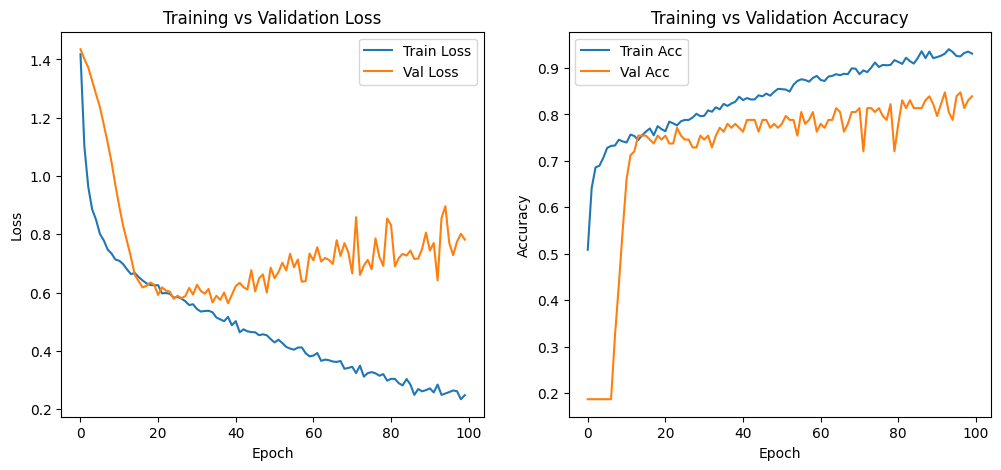

In [121]:
# Callback untuk simpan model terbaik berdasarkan val_loss
checkpoint = ModelCheckpoint(
    "best_model.h5",        # nama file hasil simpan
    monitor="val_accuracy",     # metric yang dipantau
    mode="max",             # karena accuracy lebih besar lebih baik
    save_best_only=True,    # hanya simpan model terbaik
    verbose=1
)

# Callback EarlyStopping (opsional, biar training berhenti kalau sudah mentok)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,           # hentikan training jika 20 epoch tidak ada peningkatan
    restore_best_weights=True,
    verbose=1
)

# Training dengan callback
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]   # tambahkan callback di sini
)

# Simpan history
np.save("history.npy", history.history)

# Evaluasi di test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🔎 Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Plot training vs validation loss & accuracy
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [122]:
from tensorflow.keras.models import load_model

# Load model dari file .h5
model = load_model("best_model.h5")

Test Accuracy: 0.7692
Test Loss: 0.8039
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


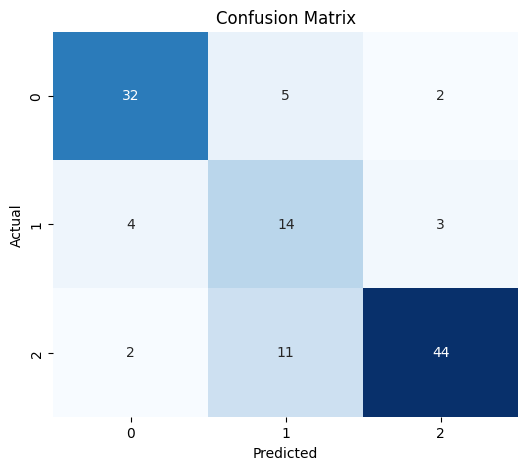


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        39
           1       0.47      0.67      0.55        21
           2       0.90      0.77      0.83        57

    accuracy                           0.77       117
   macro avg       0.74      0.75      0.74       117
weighted avg       0.80      0.77      0.78       117



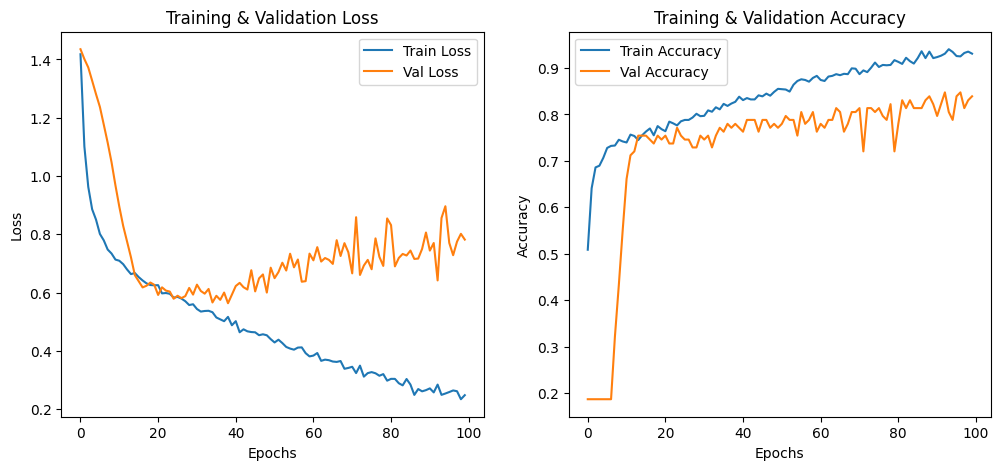

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# 1. Load model
model = load_model("best_model.h5")

labels_order = [0, 1, 2]

# 2. Evaluasi model di test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

# 3. Prediksi kelas
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred,labels=labels_order)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. (Opsional) Plot Training History kalau kamu masih punya 'history'
# Misalnya kamu sebelumnya menyimpan history ke file .npy
# np.save("history.npy", history.history)
# lalu load ulang:
try:
    history_dict = np.load("history.npy", allow_pickle=True).item()

    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.title("Training & Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()
except:
    print("⚠️ History training tidak ditemukan. Simpan dulu saat training pakai np.save('history.npy', history.history)")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test Accuracy: 0.7692

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        39
           1       0.47      0.67      0.55        21
           2       0.90      0.77      0.83        57

    accuracy                           0.77       117
   macro avg       0.74      0.75      0.74       117
weighted avg       0.80      0.77      0.78       117

Class 0 -> Precision: 0.8421, Recall: 0.8205, F1-score: 0.8312
Class 1 -> Precision: 0.4667, Recall: 0.6667, F1-score: 0.5490
Class 2 -> Precision: 0.8980, Recall: 0.7719, F1-score: 0.8302

Macro Avg -> Precision: 0.7356, Recall: 0.7530, F1-score: 0.7368
Weighted Avg -> Precision: 0.8019, Recall: 0.7692, F1-score: 0.7800


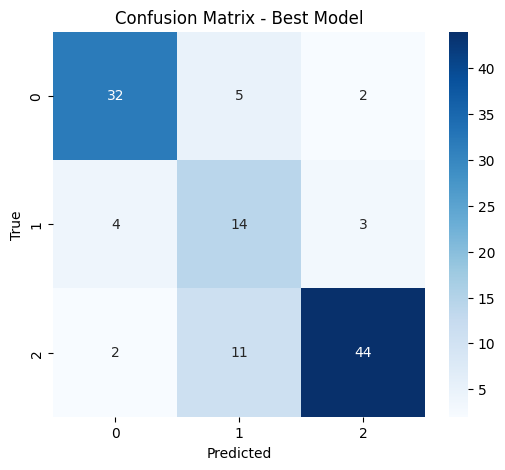

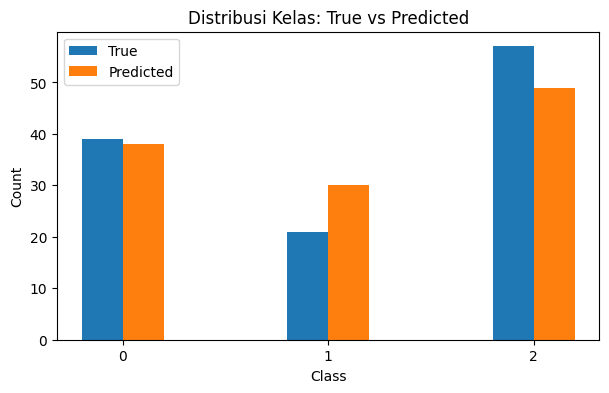

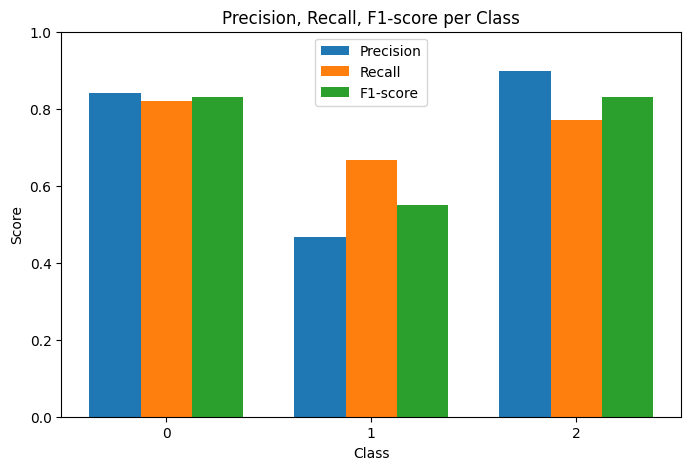

In [127]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 🔹 Prediksi di test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 🔹 Ambil label asli dari LabelEncoder
#class_names = le.classes_
class_names = ["0", "1", "2"]

# 🔹 Classification report (dict & print) pakai target_names
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 🔹 Tampilkan precision, recall, f1 tiap kelas
for label in class_names:
    print(f"Class {label} -> Precision: {report[label]['precision']:.4f}, "
          f"Recall: {report[label]['recall']:.4f}, "
          f"F1-score: {report[label]['f1-score']:.4f}")

print("\nMacro Avg -> "
      f"Precision: {report['macro avg']['precision']:.4f}, "
      f"Recall: {report['macro avg']['recall']:.4f}, "
      f"F1-score: {report['macro avg']['f1-score']:.4f}")

print("Weighted Avg -> "
      f"Precision: {report['weighted avg']['precision']:.4f}, "
      f"Recall: {report['weighted avg']['recall']:.4f}, "
      f"F1-score: {report['weighted avg']['f1-score']:.4f}")

# 🔹 Confusion Matrix dengan label asli
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best Model")
plt.show()

# 🔹 Plot distribusi prediksi vs ground truth
plt.figure(figsize=(7,4))
plt.hist([y_test, y_pred], bins=np.arange(len(class_names)+1)-0.5,
         label=["True", "Predicted"], rwidth=0.4)
plt.xticks(np.arange(len(class_names)), class_names)
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()
plt.title("Distribusi Kelas: True vs Predicted")
plt.show()

# 🔹 Bar chart precision, recall, f1-score per kelas
labels = class_names
precision = [report[l]['precision'] for l in labels]
recall = [report[l]['recall'] for l in labels]
f1 = [report[l]['f1-score'] for l in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.show()


---